Decision Tree using Gini Index

In [1]:
import os
import glob
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DIR = "/content/drive/My Drive/Colab Notebooks/DATA/"
os.chdir(DIR)

Mounted at /content/drive


In [3]:
os.chdir(DIR)
!ls

1612					insurance.csv
1712					ioc_feed.xml
1812					load_all_to_dataframe.py
1912					netflow.jsonl
1_Python_Introduction.gdoc		packet_in_flood
1_Python_Introduction.pdf		plain_and_hashes.txt
2012					plain_and_hash.txt
2611					plain.txt
3108					PlayTennis.csv
5					PlayTennisTest.csv
alerts.json				p_saltnHash.tsv
auth_logs.csv				salted_sha256.tsv
cereal.csv				security_policy.yml
CODES					soc_alerts.xlsx
controller_cpu_mem_flow_exhaustion.csv	soc_dump.sql
controller_cpu_mem_normal_traffic.csv	SSLC_Scores_1.txt
controller_cpu_mem_packet_in.csv	SSLC_Scores.csv
CYS					SSLC_Scores.json
Data_Cleaning_Practice_Teacher.ipynb	SSLC_Scores.tsv
data.csv				SSLC_Scores.txt
Daywise.txt				student.xlsx
dns_queries.tsv				superstore.csv
FI_Comments				traffic_pcap_README.txt
flow_table_exhaustion			unclean_data.csv
hashes.txt				web_access.log
incident_notes.txt


In [4]:
datafile1='PlayTennis.csv'
filename1 = DIR+'/'+datafile1 # csv file
df= pd.read_csv(filename1)
df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [5]:
t = df.keys()[-1]
print('Target Attribute is: ', t)
# Get the attribute names from input dataset
attribute_names = list(df.keys())
#Remove the target attribute from the attribute names list
attribute_names.remove(t)
print('Predicting Attributes: ', attribute_names)

Target Attribute is:  PlayTennis
Predicting Attributes:  ['Outlook', 'Temperature', 'Humidity', 'Wind']


In [6]:
# Function to calculate Gini impurity
def gini_of_list(ls, value):
    from collections import Counter
    cnt = Counter(x for x in ls)
    print('Target attribute class count(Yes/No)=', dict(cnt))
    total_instances = len(ls)
    print("Total no of instances =", total_instances)

    probs = [x / total_instances for x in cnt.values()]
    print('Class probabilities of', value, '=', probs)

    gini = 1 - sum([prob**2 for prob in probs])
    print('Gini Index of', value, 'is:', gini)
    return gini

In [7]:
def gini_index(df, split_attribute, target_attribute, battr):
    print("\n\n-----Gini Index Calculation of", split_attribute, "--------")
    df_split = df.groupby(split_attribute)
    glist = []

    for gname, group in df_split:
        print('Grouped Attribute Values \n', group)
        glist.append(gname)

    glist.reverse()
    nobs = len(df.index) * 1.0

    df_agg1 = df_split.agg({
        target_attribute: lambda x: gini_of_list(x, glist.pop())
    })

    print('\n\n Gini value of each group:')
    print(df_agg1)

    df_agg2 = df_split.agg({
        target_attribute: lambda x: len(x) / nobs
    })

    print('\n\n Weight of each group:')
    print(df_agg2)

    df_agg_ig = pd.concat([df_agg1, df_agg2], axis=1)
    df_agg_ig.columns = ['Gini', 'Weight']
    print('\n\n Gini and Weight of each group:')
    print(df_agg_ig)

    weighted_gini = sum(df_agg_ig['Gini'] * df_agg_ig['Weight'])
    print('\nWeighted Gini for attribute', split_attribute, 'is:', weighted_gini)
    return weighted_gini

In [8]:
def gini_tree(df, target_attribute, attribute_names, default_class=None, default_attr='S'):

    from collections import Counter
    cnt = Counter(x for x in df[target_attribute])

    # First check: if the dataset is pure
    if len(cnt) == 1:
        return next(iter(cnt))

    # Second check: if dataset is empty or no attributes are left
    elif df.empty or (not attribute_names):
        return default_class

    # Third check: default class for this node = majority class
    else:
        default_class = max(cnt.keys(), key=lambda k: cnt[k])

        # Select the attribute with minimum weighted Gini
        gini_values = [gini_index(df, attr, target_attribute, default_attr) for attr in attribute_names]
        min_index = gini_values.index(min(gini_values))
        best_attr = attribute_names[min_index]

        tree = {best_attr: {}}
        remaining_attributes = [i for i in attribute_names if i != best_attr]

        for attr_val, data_subset in df.groupby(best_attr):
            subtree = gini_tree(data_subset.drop(columns=[best_attr]),
                                target_attribute,
                                remaining_attributes,
                                default_class,
                                attr_val)
            tree[best_attr][attr_val] = subtree

        return tree

In [9]:
from pprint import pprint
tree = gini_tree(df, t, attribute_names)
print("\nThe Resultant Decision Tree using Gini Index is:")
pprint(tree)



-----Gini Index Calculation of Outlook --------
Grouped Attribute Values 
      Outlook Temperature Humidity    Wind PlayTennis
2   Overcast         Hot     High    Weak        Yes
6   Overcast        Cool   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
Grouped Attribute Values 
    Outlook Temperature Humidity    Wind PlayTennis
3     Rain        Mild     High    Weak        Yes
4     Rain        Cool   Normal    Weak        Yes
5     Rain        Cool   Normal  Strong         No
9     Rain        Mild   Normal    Weak        Yes
13    Rain        Mild     High  Strong         No
Grouped Attribute Values 
    Outlook Temperature Humidity    Wind PlayTennis
0    Sunny         Hot     High    Weak         No
1    Sunny         Hot     High  Strong         No
7    Sunny        Mild     High    Weak         No
8    Sunny        Cool   Normal    Weak        Yes
10   Sunny        Mild   Normal  Strong    

In [10]:
def classify(instance, tree,default=None): # Instance of Play Tennis with Predicted
    attribute = next(iter(tree)) # Outlook/Humidity/Wind
    if instance[attribute] in tree[attribute].keys(): # Value of the attributs in  set of Tree keys
        result = tree[attribute][instance[attribute]]
        if isinstance(result, dict): # this is a tree, delve deeper
            return classify(instance, result)
        else:
            return result # this is a label
    else:
        return default

In [11]:
df_new=pd.read_csv('PlayTennisTest.csv')
df_new['predicted'] = df_new.apply(classify, axis=1, args=(tree,'?'))
print(df_new)

  Outlook Temperature Humidity    Wind PlayTennis predicted
0   Sunny         Hot   Normal    Weak          ?       Yes
1    Rain        Mild     High  Strong          ?        No


In [12]:
!pip install graphviz

In [13]:
from graphviz import Digraph

def add_nodes_edges(tree, dot=None, parent=None, edge_label=""):
    if dot is None:
        dot = Digraph()
        dot.attr("node", shape="box")

    if isinstance(tree, dict):
        for root, branches in tree.items():
            node_id = str(id(branches)) + root
            dot.node(node_id, root)

            if parent is not None:
                dot.edge(parent, node_id, label=edge_label)

            for branch_value, subtree in branches.items():
                add_nodes_edges(subtree, dot, node_id, str(branch_value))
    else:
        leaf_id = str(id(tree)) + str(tree)
        dot.node(leaf_id, str(tree), shape="ellipse")
        if parent is not None:
            dot.edge(parent, leaf_id, label=edge_label)

    return dot

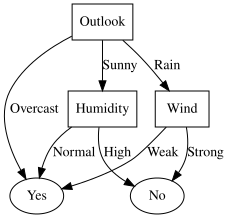

In [15]:
dot = add_nodes_edges(tree)
dot